In [1]:
import os
print(os.getcwd())

C:\waste-classifier
['.ipynb_checkpoints', 'Untitled.ipynb', 'waste_dataset']


In [2]:
import os
class_path = "waste_dataset/standardized_256"
print(os.listdir(class_path))  

for cls in os.listdir(class_path):
    count = len(os.listdir(os.path.join(class_path, cls)))
    print(cls, count)

['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
battery 756
biological 699
cardboard 1411
clothes 1892
glass 1736
metal 930
paper 1336
plastic 1597
shoes 1449
trash 453


In [8]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_names = ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
counts = [756, 699, 1411, 1892, 1736, 930, 1336, 1597, 1449, 453]

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(class_names)),
    y=np.repeat(np.arange(len(class_names)), counts)
)
class_weight_dict = dict(enumerate(class_weights))
for key, value in class_weight_dict.items():
    print(f"{key}: {value}")

0: 1.6215608465608466
1: 1.7537911301859799
2: 0.8688164422395465
3: 0.647938689217759
4: 0.7061635944700461
5: 1.3181720430107526
6: 0.9175898203592814
7: 0.7676268002504696
8: 0.846031746031746
9: 2.7061810154525388


In [9]:
import splitfolders
splitfolders.ratio("waste_dataset/standardized_256", output="split_dataset", seed=42, ratio=(.7, .15, .15))

Copying files: 12259 files [00:22, 556.83 files/s]


In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,      # randomly rotate images up to 20 degrees
    horizontal_flip=True,   # randomly flip images left-right
    zoom_range=0.2          # randomly zoom in/out up to 20%
)

val_datagen = ImageDataGenerator(rescale=1./255)  # no augmentation 

train_gen = train_datagen.flow_from_directory(
    "split_dataset/train",
    target_size=(224, 224),   # resize every image to 224x224 pixels 
    batch_size=32,             # process 32 images at a time
    class_mode="categorical"   # since there is 10 classes
)

val_gen = val_datagen.flow_from_directory(
    "split_dataset/val",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)

Found 8578 images belonging to 10 classes.
Found 1833 images belonging to 10 classes.


In [12]:
images, labels = next(train_gen)
print(images.shape)   # 32 images, 224x224 pixels, 3 color channels (RGB)
print(labels.shape)   # 32 images, 10 possible classes
print(train_gen.class_indices)  # shows which number maps to which class name

(32, 224, 224, 3)
(32, 10)
{'battery': 0, 'biological': 1, 'cardboard': 2, 'clothes': 3, 'glass': 4, 'metal': 5, 'paper': 6, 'plastic': 7, 'shoes': 8, 'trash': 9}


In [13]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Load MobileNetV2 pretrained on ImageNet, without its original classification head
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")

# Freeze it so we don't destroy what it already learned
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),        # condenses the feature maps into a single vector per image
    layers.Dense(128, activation="relu"),   # learns waste-specific patterns from those features
    layers.Dropout(0.3),                    # randomly disables 30% of neurons each step, to prevent overfitting
    layers.Dense(10, activation="softmax")  # final output layer — 10 numbers (one per class) that sum to 1
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_names = ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
counts = [756, 699, 1411, 1892, 1736, 930, 1336, 1597, 1449, 453]

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(class_names)),
    y=np.repeat(np.arange(len(class_names)), counts)
)
class_weight_dict = dict(enumerate(class_weights))

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weight_dict
)

Epoch 1/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 350s 1s/step - accuracy: 0.7400 - loss: 0.8020 - val_accuracy: 0.8434 - val_loss: 0.4640
Epoch 2/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 241s 897ms/step - accuracy: 0.8397 - loss: 0.4789 - val_accuracy: 0.8751 - val_loss: 0.3854
Epoch 3/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 217s 807ms/step - accuracy: 0.8647 - loss: 0.4054 - val_accuracy: 0.8762 - val_loss: 0.3724
Epoch 4/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 214s 795ms/step - accuracy: 0.8756 - loss: 0.3619 - val_accuracy: 0.8909 - val_loss: 0.3354
Epoch 5/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 213s 791ms/step - accuracy: 0.8870 - loss: 0.3206 - val_accuracy: 0.8942 - val_loss: 0.3333
Epoch 6/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 216s 804ms/step - accuracy: 0.9013 - loss: 0.2851 - val_accuracy: 0.8816 - val_loss: 0.3626
Epoch 7/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 256s 952ms/step - accuracy: 0.9009 - loss: 0.2776 - val_accuracy: 0.8920 - val_loss: 0.3295
Epoch 8/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 226s 840ms/step - accuracy: 0.9107 - lo

In [15]:
from sklearn.metrics import classification_report
import numpy as np

test_datagen = ImageDataGenerator(rescale=1./255)  # no augmentation, just rescale

test_gen = test_datagen.flow_from_directory(
    "split_dataset/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False  # keep order so predictions line up with true labels
)

y_pred = np.argmax(model.predict(test_gen), axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

Found 1848 images belonging to 10 classes.
58/58 ━━━━━━━━━━━━━━━━━━━━ 47s 785ms/step
              precision    recall  f1-score   support

     battery       0.91      0.94      0.93       114
  biological       0.96      0.97      0.97       106
   cardboard       0.86      0.89      0.87       213
     clothes       0.98      0.98      0.98       285
       glass       0.90      0.82      0.86       261
       metal       0.73      0.86      0.79       140
       paper       0.83      0.84      0.84       201
     plastic       0.87      0.80      0.83       241
       shoes       0.96      0.98      0.97       218
       trash       0.78      0.77      0.77        69

    accuracy                           0.89      1848
   macro avg       0.88      0.88      0.88      1848
weighted avg       0.89      0.89      0.89      1848



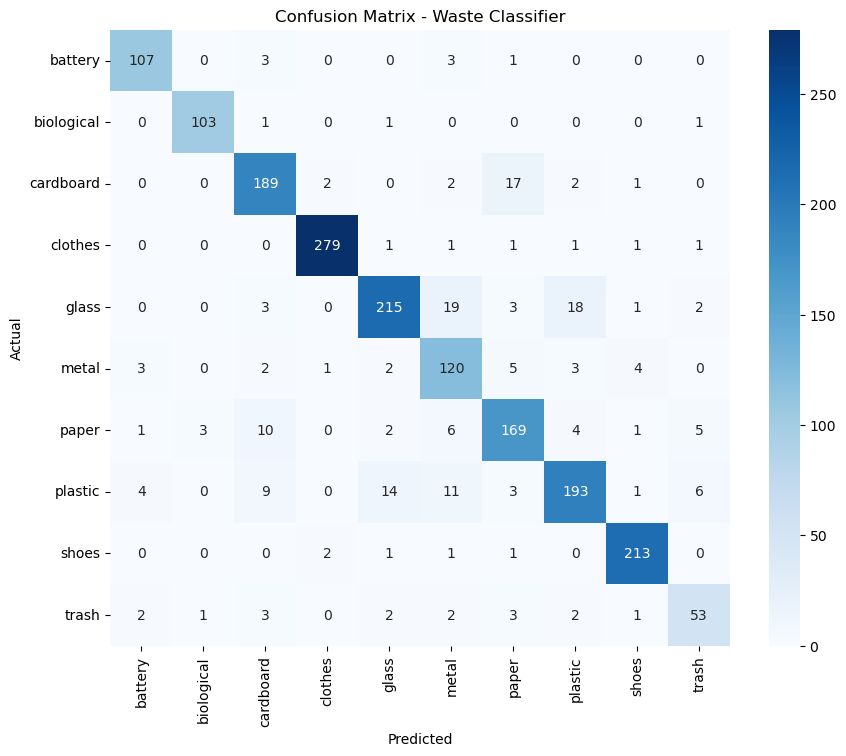

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Waste Classifier")
plt.savefig("confusion_matrix.png")
plt.show()

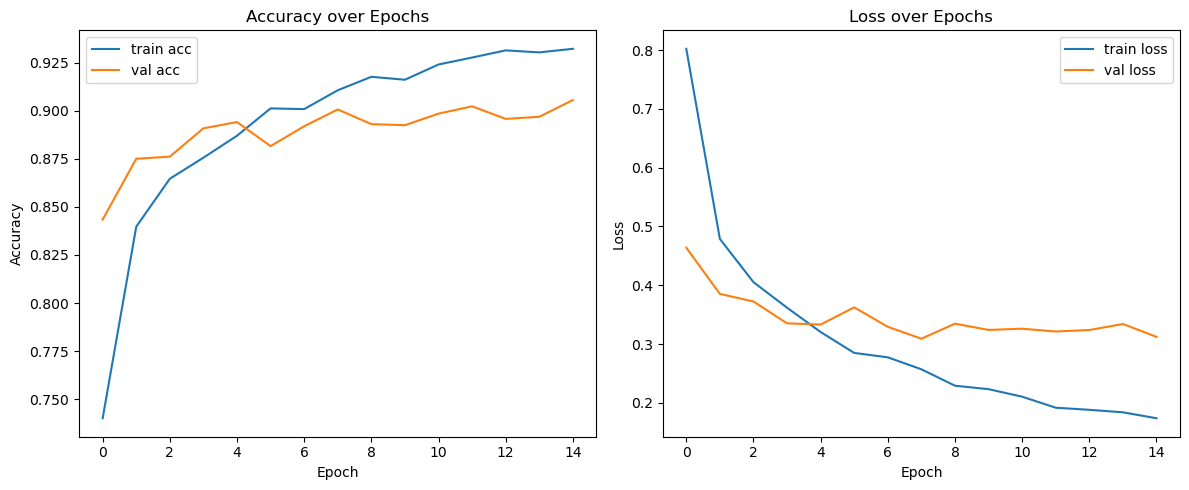

In [17]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy over Epochs")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss over Epochs")

plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()

In [18]:
model.save("waste_classifier_model.h5")

In [19]:
model.save("waste_classifier_model.keras")

In [20]:
import os
print(os.path.exists("waste_classifier_model.keras"))  

True
